<a href="https://colab.research.google.com/github/ivanovyeppez/talento-tech/blob/main/Proyectos/PROYECTO_Clasificacion_IYepez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from google.colab import drive

# Monta Google Drive para acceder al archivo CSV
drive.mount('/content/drive')

# Carga el dataset de Iris desde tu Google Drive. Asegúrate de cambiar la ruta.
df = pd.read_csv('/content/drive/MyDrive/Datasets/dataset_cancer.csv')

# Muestra las primeras filas para verificar que se cargó correctamente
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          

In [ ]:
import pandas as pd

# Cargar dataset (ya lo tienes en df)
# Elimina columna vacía
df = df.drop(columns=['Unnamed: 32'])

# Verificar valores faltantes
print(df.isnull().sum())

# Separar features y target
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis'].map({'M':1, 'B':0})  # M=1 maligno, B=0 benigno

print("Shape X:", X.shape)
print("Shape y:", y.shape)

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
Shape X: (569, 30)
Shape y: (569,)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Separar features y target
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis'].map({'M':1, 'B':0})


In [ ]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Modelo: regresión logística
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=500, random_state=42)

In [ ]:
# Predicciones
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]


In [ ]:
# ==== MÉTRICAS DE CLASIFICACIÓN ====
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9649122807017544

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



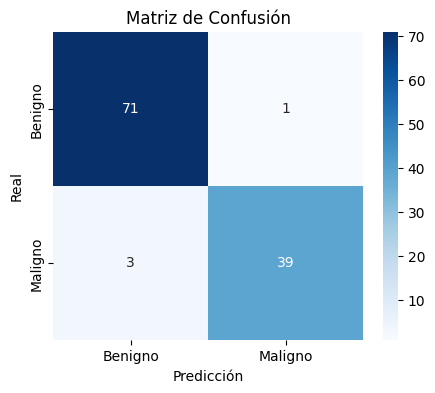

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benigno","Maligno"], yticklabels=["Benigno","Maligno"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


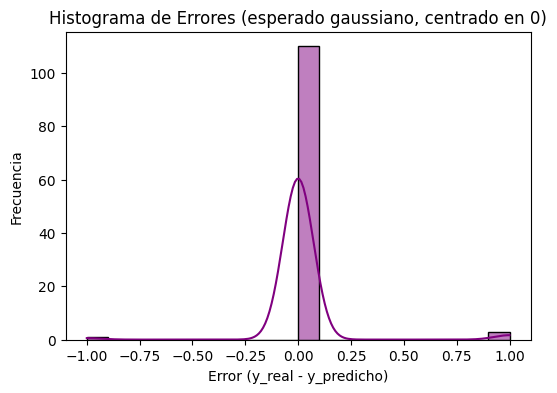

In [ ]:
# ==== HISTOGRAMA DE ERRORES ====
errores = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(errores, bins=20, kde=True, color="purple")
plt.title("Histograma de Errores (esperado gaussiano, centrado en 0)")
plt.xlabel("Error (y_real - y_predicho)")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# ==== MÉTRICAS DE REGRESIÓN ====
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100
r2 = r2_score(y_test, y_pred)

print("\nMétricas de regresión aplicadas a clasificación:")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R²:", r2)


Métricas de regresión aplicadas a clasificación:
MAE: 0.03508771929824561
RMSE: 0.1873171623163388
MAPE: 8771929827.192984
R²: 0.8492063492063492


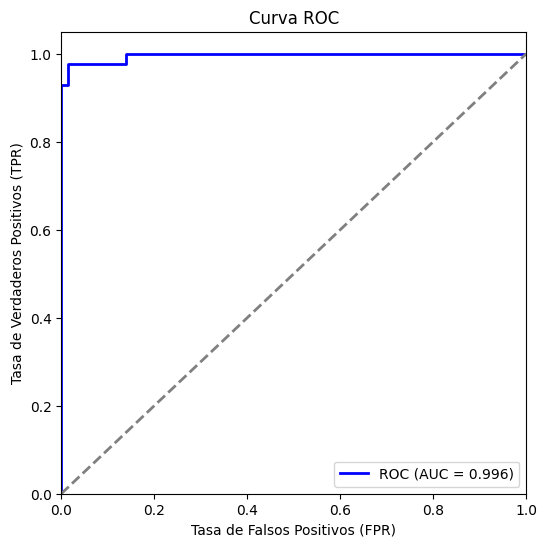

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Graficar curva ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], color="gray", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()